In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
from google.colab import drive
import missingno as msno
import geopandas as gpd
import contextily as ctx
from matplotlib.colors import LogNorm

In [3]:
drive.mount('/content/drive', force_remount=False)

DATA_PATH = Path('/content/drive/MyDrive/MDA_data/joined/cycling_weather_full.parquet')
FIG_DIR = Path('/content/drive/MyDrive/MDA_data/eda_figures')
FIG_DIR.mkdir(exist_ok=True, parents=True)

SAMPLE_FRAC = 0.05
SEED = 42

rng = np.random.default_rng(SEED)
pf = pq.ParquetFile(DATA_PATH)
parts = []
for batch in pf.iter_batches(batch_size=200_000):
    b = batch.to_pandas()
    parts.append(b.loc[rng.random(len(b)) < SAMPLE_FRAC])
df = pd.concat(parts, ignore_index=True)

# Convert UTC to belgian local time.
df['ts_local'] = df['ts'].dt.tz_convert('Europe/Brussels')
df['hour'] = df['ts_local'].dt.hour
df['dayofweek'] = df['ts_local'].dt.dayofweek
df['month'] = df['ts_local'].dt.month
df['is_weekend'] = df['dayofweek'] >= 5

print(f"loaded {len(df):,} rows, {df['site_id'].nunique()} sites")
print(f"period: {df['ts'].min().date()} to {df['ts'].max().date()}")

Mounted at /content/drive
loaded 2,034,900 rows, 150 sites
period: 2019-10-01 to 2026-03-01


In [5]:
# Variable summary table for the data section of the report
num_cols = ['count', 'precip_quantity', 'temp_dry_shelter_avg', 'wind_speed_10m',
            'wind_gusts_speed', 'humidity_rel_shelter_avg', 'pressure',
            'sun_duration', 'short_wave_from_sky_avg']
summary = df[num_cols].describe(percentiles=[0.5, 0.95]).T.round(2)
summary['pct_missing'] = (df[num_cols].isna().mean() * 100).round(2).values
print(summary)


# Bin precipitation into dry/light/moderate/heavy and look at average cycling counts
df['rain_bin'] = pd.cut(df['precip_quantity'],
                        bins=[-0.01, 0, 0.5, 2, 100],
                        labels=['dry', 'light', 'moderate', 'heavy'])
rain_tbl = df.dropna(subset=['count', 'rain_bin']).groupby('rain_bin', observed=True)['count'].agg(['mean', 'count']).round(2)
print(rain_tbl)

                              count     mean     std     min      50%  \
count                     1982608.0     2.56    6.99    0.00     0.00   
precip_quantity           2034900.0     0.02    0.17    0.00     0.00   
temp_dry_shelter_avg      2033823.0    11.82    6.79  -38.88    11.59   
wind_speed_10m            1765505.0     3.35    2.15    0.03     2.95   
wind_gusts_speed          2030192.0     5.53    3.38    0.03     4.99   
humidity_rel_shelter_avg  2033944.0    81.13   16.31   11.94    85.55   
pressure                  2034085.0  1011.05   11.13  952.04  1012.01   
sun_duration              2034900.0     3.19    6.18    0.00     0.00   
short_wave_from_sky_avg   1902528.0   121.81  206.58  -22.69     0.00   

                              95%      max  pct_missing  
count                       12.00  1264.00         2.57  
precip_quantity              0.09    25.75         0.00  
temp_dry_shelter_avg        23.19    38.55         0.05  
wind_speed_10m               7.43    

In [ ]:
# Missing values across the whole sample.
print('missing values per column:')
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2)
}).sort_values('pct_missing', ascending=False)
print(missing[missing['n_missing'] > 0])

site_missing = df.groupby('site_id')[num_cols].apply(lambda x: x.isna().mean() * 100).round(1)
print(f"\nsites with >10% missing in any weather variable: "
      f"{(site_missing > 10).any(axis=1).sum()} out of {len(site_missing)}")

# Plot 0: missing value analysis on weather variables
msno.matrix(df.sample(5000, random_state=SEED)[num_cols])
plt.title('Missing value pattern (5k random rows)')
plt.savefig(FIG_DIR / 'fig0_missing.png', bbox_inches='tight')
plt.show()

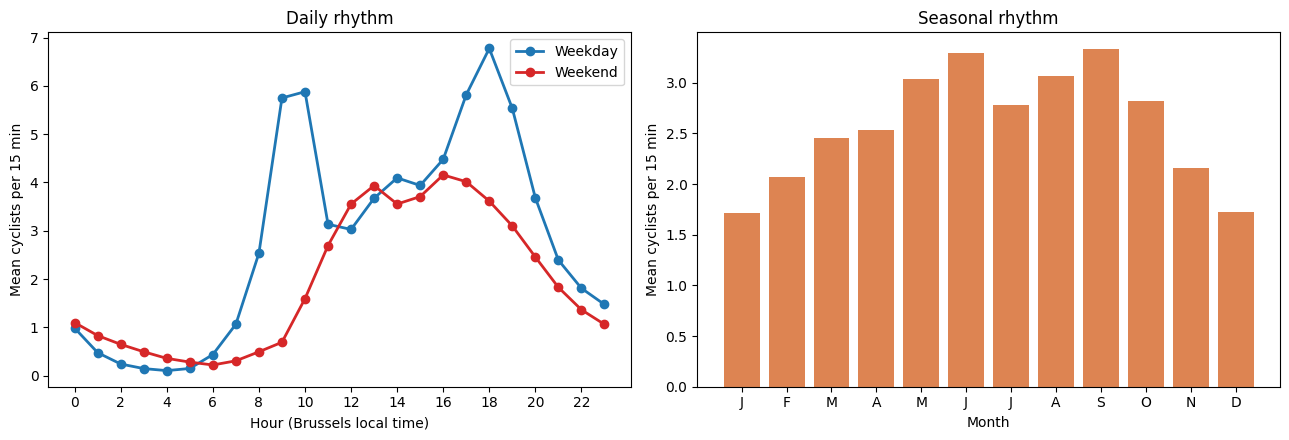

In [6]:
# Plot 1: cycling rhythm by hour, split by weekend vs weekday
hourly = df.groupby(['hour', 'is_weekend'], observed=True)['count'].mean().reset_index()

plt.figure(figsize=(13, 4.5))
plt.subplot(1, 2, 1)
for is_we, lbl, c in [(False, 'Weekday', '#1f77b4'), (True, 'Weekend', '#d62728')]:
    sub = hourly[hourly['is_weekend'] == is_we]
    plt.plot(sub['hour'], sub['count'], 'o-', label=lbl, color=c, linewidth=2)
plt.xticks(range(0, 24, 2))
plt.xlabel('Hour (Brussels local time)')
plt.ylabel('Mean cyclists per 15 min')
plt.title('Daily rhythm')
plt.legend()

# Monthly distribution
plt.subplot(1, 2, 2)
monthly = df.groupby('month')['count'].mean()
plt.bar(monthly.index, monthly.values, color='#dd8452')
plt.xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.xlabel('Month')
plt.ylabel('Mean cyclists per 15 min')
plt.title('Seasonal rhythm')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_temporal_patterns.png', bbox_inches='tight')
plt.show()

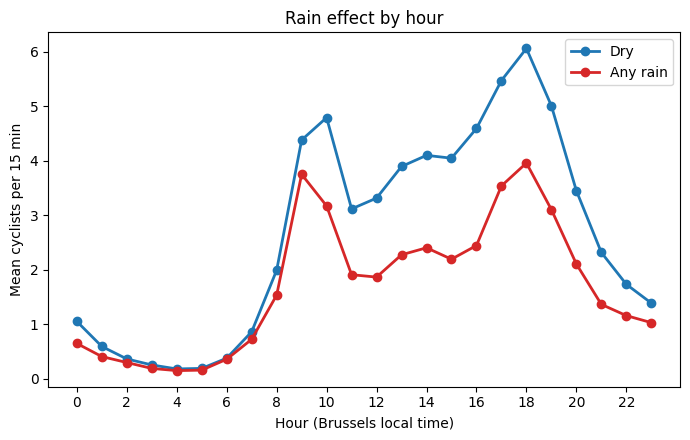

In [7]:
# Plot 2: rain effect hourly
rain_by_hour = df.dropna(subset=['count', 'precip_quantity']).copy()
rain_by_hour['wet'] = rain_by_hour['precip_quantity'] > 0
rain_by_hour = rain_by_hour.groupby(['hour', 'wet'])['count'].mean().reset_index()

plt.figure(figsize=(7, 4.5))
for wet, lbl, c in [(False, 'Dry', '#1f77b4'), (True, 'Any rain', '#d62728')]:
    sub = rain_by_hour[rain_by_hour['wet'] == wet]
    plt.plot(sub['hour'], sub['count'], 'o-', label=lbl, color=c, linewidth=2)
plt.xticks(range(0, 24, 2))
plt.xlabel('Hour (Brussels local time)')
plt.ylabel('Mean cyclists per 15 min')
plt.title('Rain effect by hour')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_rain_by_hour.png', bbox_inches='tight')
plt.show()


# Compute per-site rain sensitivity: percent drop in cycling when it rains.
site_stats = df.dropna(subset=['count', 'precip_quantity']).copy()
site_stats['wet'] = site_stats['precip_quantity'] > 0.1
site_stats = site_stats.groupby(['site_id', 'wet'])['count'].mean().unstack('wet').dropna()
site_stats.columns = ['dry_mean', 'wet_mean']
site_stats['rain_drop_pct'] = 100 * (site_stats['wet_mean'] - site_stats['dry_mean']) / site_stats['dry_mean']

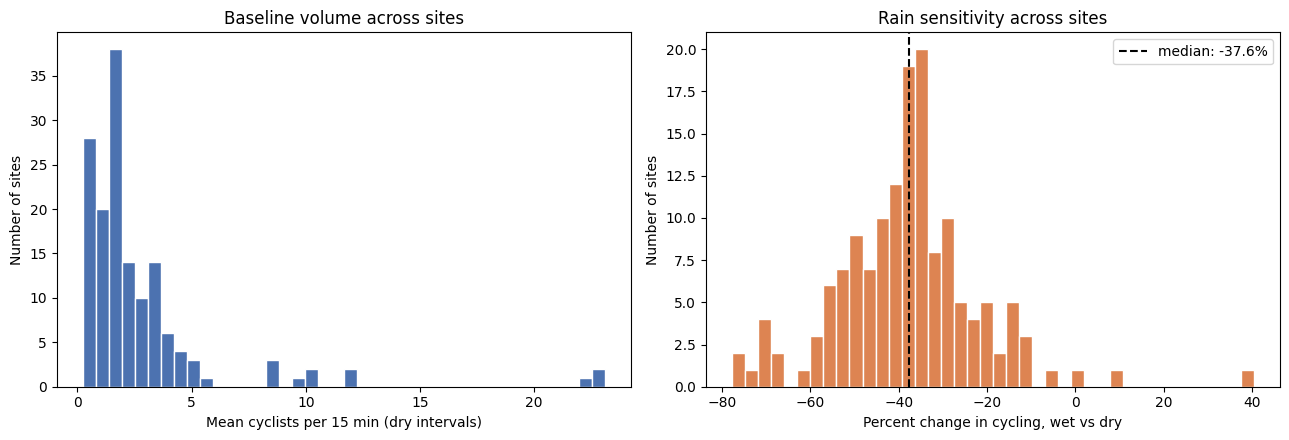

In [8]:
# Plot 3: distribution of baseline volume and rain sensitivity across sites
plt.figure(figsize=(13, 4.5))
plt.subplot(1, 2, 1)
plt.hist(site_stats['dry_mean'], bins=40, color='#4c72b0', edgecolor='white')
plt.xlabel('Mean cyclists per 15 min (dry intervals)')
plt.ylabel('Number of sites')
plt.title('Baseline volume across sites')

plt.subplot(1, 2, 2)
plt.hist(site_stats['rain_drop_pct'].clip(-100, 50), bins=40, color='#dd8452', edgecolor='white')
plt.axvline(site_stats['rain_drop_pct'].median(), color='black', linestyle='--',
            label=f"median: {site_stats['rain_drop_pct'].median():.1f}%")
plt.xlabel('Percent change in cycling, wet vs dry')
plt.ylabel('Number of sites')
plt.title('Rain sensitivity across sites')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_site_heterogeneity.png', bbox_inches='tight')
plt.show()

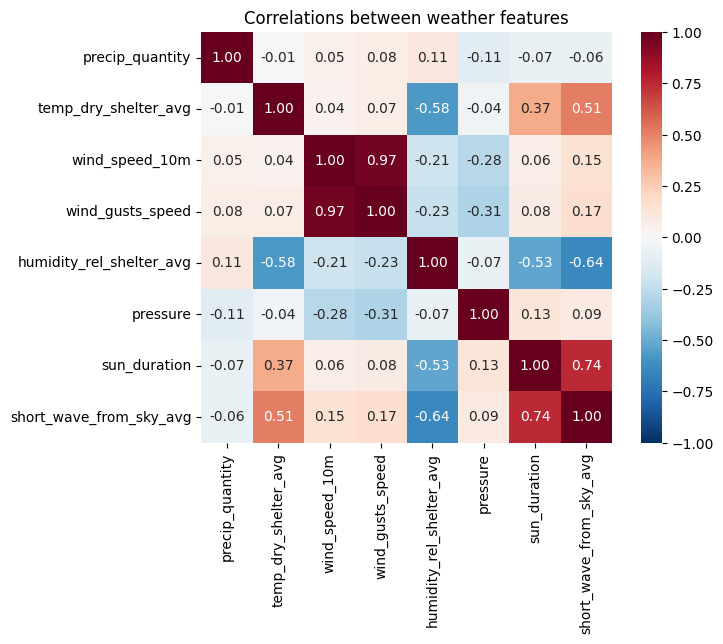

In [9]:
# Plot 4: correlation matrix of weather features.
weather_cols = ['precip_quantity', 'temp_dry_shelter_avg', 'wind_speed_10m',
                'wind_gusts_speed', 'humidity_rel_shelter_avg', 'pressure',
                'sun_duration', 'short_wave_from_sky_avg']
corr_matrix = df[weather_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlations between weather features')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_weather_correlations.png', bbox_inches='tight')
plt.show()

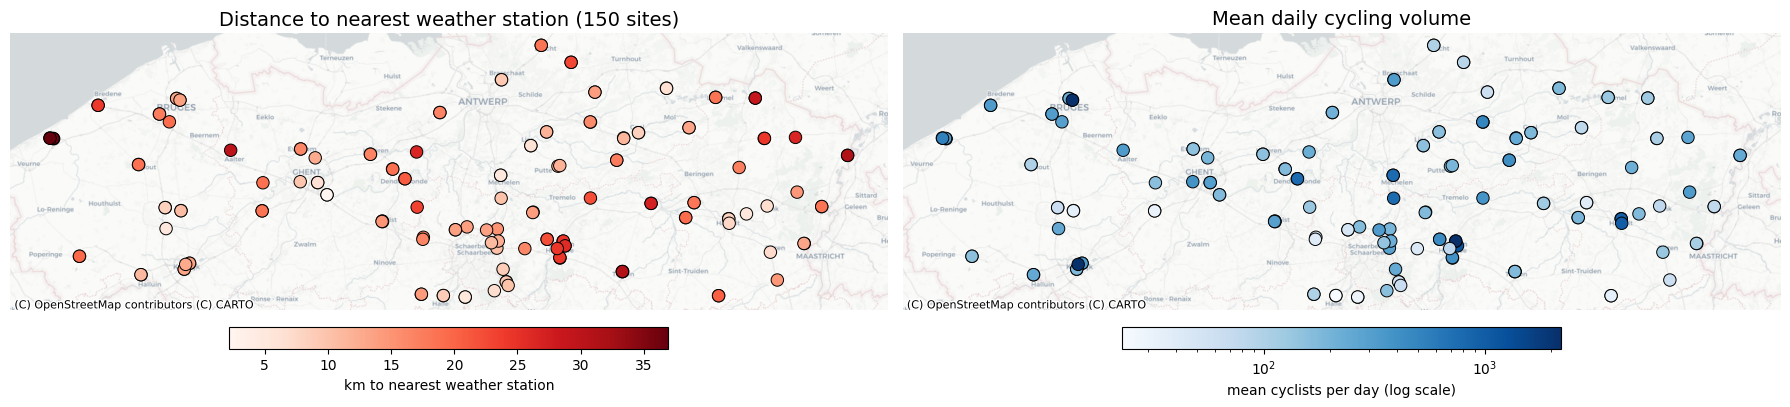

In [26]:
site_geo = df.groupby('site_id').agg(
    site_lat=('site_lat', 'first'),
    site_lon=('site_lon', 'first'),
    mean_count=('count', 'mean'),
    nearest_station_km=('nearest_station_km', 'first')
).reset_index()
site_geo['mean_daily'] = site_geo['mean_count'] * 96

gdf = gpd.GeoDataFrame(site_geo,
                       geometry=gpd.points_from_xy(site_geo['site_lon'], site_geo['site_lat']),
                       crs='EPSG:4326').to_crs(epsg=3857)

# Plot left: distance to nearest weather station.
# Plot right: Mean daily cyclists
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

gdf.plot(ax=axes[0], column='nearest_station_km', cmap='Reds',
         markersize=80, edgecolor='black', linewidth=0.7, legend=True,
         legend_kwds={'label': 'km to nearest weather station',
                      'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02})
ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron, zoom=9)
axes[0].set_title(f'Distance to nearest weather station ({len(gdf)} sites)', fontsize=14)
axes[0].axis('off')

gdf.plot(ax=axes[1], column='mean_daily', cmap='Blues',
         markersize=80, edgecolor='black', linewidth=0.7, legend=True,
         norm=LogNorm(vmin=max(gdf['mean_daily'].min(), 1), vmax=gdf['mean_daily'].max()),
         legend_kwds={'label': 'mean cyclists per day (log scale)',
                      'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02})
ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron, zoom=9)
axes[1].set_title('Mean daily cycling volume', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_site_map.png', bbox_inches='tight', dpi=150)
plt.show()